# 1D Schrödinger Equation Playground

This notebook is a self-contained starting point for exploring wavefunction dynamics.  
It is organized into five sections:

1. **Imports** — load all local modules  
2. **Grid** — set up the spatial and time grids  
3. **Potential** — choose (or compose) a potential  
4. **Initial state** — pick a starting wavefunction  
5. **Simulate & visualize** — run the propagator and make a movie  

The default example is a Gaussian wavepacket scattering off a soft barrier.  
Swap in any potential or initial state from the catalogue below.

---
## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video

# --- local modules (must be in the same directory as this notebook) ---
from schrodinger_solver_1d import (
    make_grid,                   # build the spatial / k-space grid
    split_step_propagate,        # 2nd-order Strang split-step solver
    yoshida_step_propagate,      # 4th-order Yoshida solver (higher accuracy)
)

from potentials_1d import (
    # --- static potentials ---
    HarmonicPotential, OmegaConstant, OmegaRamp,
    QuarticPotential,
    QuarticDoubleWell,
    TiltedQuarticDoubleWell,
    EvolvingQuarticDoubleWell,
    GaussianWell,
    SoftBarrier,
    SquareBarrier,
    # --- utilities ---
    CachedPotential,             # wrap a time-independent potential for a speed boost
    ComplexAbsorbingPotential,   # absorb probability near the domain walls
    Vsum,                        # add two (or more) potentials together
)

from wavefunctions import (
    gaussian_wavepacket,         # moving Gaussian — good for scattering
    gaussian_wavepacket_energy,  # mean energy of the wavepacket
    ho_eigenstate,               # harmonic oscillator eigenstate
    ho_energy                    # energies of harmonic oscillator states
)

from wavefunction_movies import make_movie

print('Modules loaded.')

Modules loaded.


---
## 2. Grid

The solver works with a uniform grid on the interval $[-L, L)$ with $N$ points.

| Parameter | Typical range | Effect |
|-----------|--------------|--------|
| `N` | 512 – 8192 | spatial resolution (use a power of 2 for FFT efficiency) |
| `y_max` | 10 – 20 | half-width of the domain |

**Rule of thumb:** the highest representable wavenumber is $k_\max = \pi N / (2 L)$.  
Your wavepacket's central momentum `k0` should satisfy $|k_0| \ll k_\max$.

In [2]:
N    = 2**12    # number of grid points (power of 2 keeps FFTs fast)
y_max = 12.0   # domain runs from -y_max to +y_max

grid = make_grid(N, y_max)

print(f'Grid: N={N}, y in [{-y_max}, {y_max})')
print(f'  dy       = {grid.dy:.4f}')
print(f'  k_max    = {grid.kmax:.2f}   (max representable wavenumber)')

Grid: N=4096, y in [-12.0, 12.0)
  dy       = 0.0059
  k_max    = 536.17   (max representable wavenumber)


---
## 3. Potential

Choose one of the blocks below (uncomment it and comment the others), or compose
multiple potentials with `Vsum(V1, V2, ...)`.

All potential callables have the signature `V(y, tau) -> np.ndarray`.

Wrapping a time-independent potential in `CachedPotential` pre-computes the
potential array once and reuses it every time step — a significant speed-up.

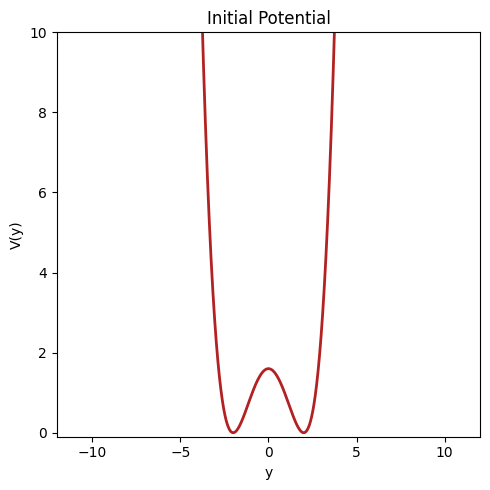

In [3]:
# ============================================================
#  OPTION A (default): Gaussian wavepacket + soft barrier
#  Great for watching partial reflection and tunnelling.
# ============================================================
#V_raw = SoftBarrier(v0=8.0,    # barrier height (set below E_packet for tunnelling)
#                    delta=0.1, # edge sharpness (smaller = sharper)
#                    w=0.4,     # barrier width
#                    x0=0.0)    # barrier centre

# ============================================================
#  OPTION B: Harmonic oscillator with constant frequency
#  Start with a displaced coherent state (gaussian_wavepacket
#  with k0=0 and y0 != 0) to watch it oscillate.
# ============================================================
# omega = 1.0
# V_raw = HarmonicPotential(OmegaConstant(omega))

# ============================================================
#  OPTION C: Harmonic oscillator with a frequency ramp
#  omega ramps from omega_i to omega_f at time tau0.
# ============================================================
# V_raw = HarmonicPotential(OmegaRamp(omega_i=1.0, omega_f=2.0,
#                                      tau0=5.0, delta=1.0))

# ============================================================
#  OPTION D: Quartic double well
#  V(y) = lam*(y^2 - a^2)^2 — two wells at y = ±a.
#  Start in one well; watch tunnelling.
# ============================================================
a = 2.0
lam = 0.10
omega_qdw = np.sqrt(8.0*lam*a*a)         # frequency of a single well
V_raw = QuarticDoubleWell(lam=lam, a=a)

# ============================================================
#  OPTION D 2: Tilted Quartic double well
#  V(y) = lam*(y^2 - a^2)^2 - epsilon*y — two wells at y = ±a.
#  Start in one well; watch tunnelling.
# ============================================================
#a = 2.0
#lam = 0.125
#epsilon = 0.10
#omega_qdw = np.sqrt(8.0*lam*a*a)         # frequency of a single well
#V_raw = TiltedQuarticDoubleWell(lam=lam, a=a, epsilon=epsilon)

# ============================================================
#  OPTION E: Gaussian well (bound-state trapping)
# ============================================================
# V_raw = GaussianWell(V0=5.0, sigma=1.0)   # note: depth is -V0

# ============================================================
#  OPTION F: Sum of two potentials
#  e.g. harmonic trap + a central barrier
# ============================================================
# V_raw = Vsum(HarmonicPotential(OmegaConstant(1.0)),
#              SoftBarrier(v0=3.0, delta=0.1, w=0.3, x0=0.0))


# --- Wrap in CachedPotential if V does NOT depend on time
#     (this is the case for Options A, B-static, D, E, F).
#     For time-dependent V (Options B-ramp, C) skip the wrapper
#     and pass time_independent=False to the propagator.
V = CachedPotential(V_raw)


# ============================================================
#  OPTION G: Time Dependent Double Quartic Well
#
#  V(y,tau) = lam*(y^2 - a^2)^2 - epsilon(tau)*y — two wells at y = ±a.
#  
#   epsilon(tau) = eps0*tan( (tau-t0)/tau_sweep )
#            
# ============================================================
#a         = 2.000
#lam       = 0.120
#omega_qdw = np.sqrt(8.0*lam*a*a)
#eps0      = -0.250
#t0        = 5.000
#tau_sweep = 0.010
#V = EvolvingQuarticDoubleWell(lam=lam,a=a,eps0=eps0,t0=t0,tau_sweep=tau_sweep)
#   


# --- Quick sanity plot of the initial potential
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(grid.y, V(grid.y, 0.0), color='firebrick', lw=2)
ax.set_xlabel('y')
ax.set_ylabel('V(y)')
ax.set_title('Initial Potential')
ax.set_xlim(-y_max, y_max)
ax.set_ylim(-0.10,10.0)
plt.tight_layout()
plt.show()

---
## 4. Initial state

Choose one of the blocks below to set `psi0`.

| State | Good for |
|-------|----------|
| `gaussian_wavepacket` | scattering, free propagation |
| `ho_eigenstate` | harmonic-trap dynamics |
| custom array | anything else (will be normalized automatically) |

Initial state energy : 0.500
Barrier height       : 1.600
E / V_barrier        : 0.312   (>1 → classically over-barrier, <1 → tunnelling regime)


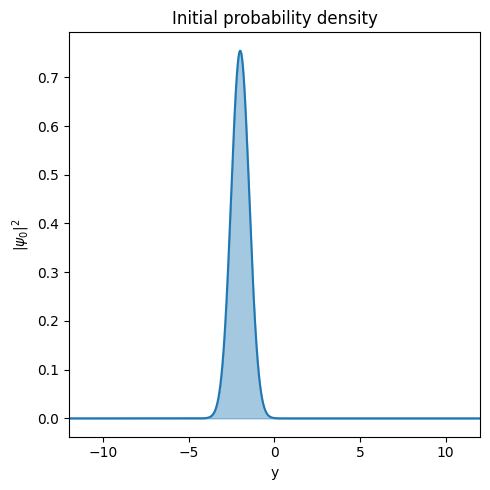

In [4]:
# ============================================================
#  OPTION A (default): moving Gaussian wavepacket
#  y0    — starting centre of the packet
#  k0    — central momentum (>0 moves right)
#  sigma — spatial width (position uncertainty)
#
#  to choose sigma based on QuarticDoubleWell, use omega_qdw calculated above
#
# ============================================================
#y0    = -a      # start position
#k0    =  0.00   # mean momentum (positive moves right)
#sigma =  0.50   # width
#sigma = 1.0/np.sqrt(2.0*omega_qdw) # width

#psi0 = gaussian_wavepacket(grid.y, y0=y0, k0=k0, sigma=sigma)

#E_packet = gaussian_wavepacket_energy(k0, sigma)
#V_barrier = float(V(np.array([0.0]), 0.0)[0])   # potential at barrier centre
#print(f'Mean packet energy : {E_packet:.3f}')
#print(f'Barrier height     : {V_barrier:.3f}')
#print(f'E / V_barrier      : {E_packet/V_barrier:.3f}   '
#      f'(>1 → classically over-barrier, <1 → tunnelling regime)')
#---

# ============================================================
#  OPTION B: harmonic-oscillator ground state displaced from centre
#  (coherent state — oscillates without spreading)
# ============================================================
omega = omega_qdw
n_ho = 0
psi0  = ho_eigenstate(grid.y + a, n=n_ho, Omega=omega)  # displace by using y - delta_y
E_packet = ho_energy(n_ho)
V_barrier = float(V(np.array([0.0]), 0.0)[0])   # potential at barrier centre
print(f'Initial state energy : {E_packet:.3f}')
print(f'Barrier height       : {V_barrier:.3f}')
print(f'E / V_barrier        : {E_packet/V_barrier:.3f}   '
      f'(>1 → classically over-barrier, <1 → tunnelling regime)')

# ============================================================
#  OPTION C: superposition of two harmonic-oscillator eigenstates
#  (beats at frequency Delta E = E_1 - E_0 = omega)
# ============================================================
# omega = 1.0
# psi0  = (ho_eigenstate(grid.y, n=0, Omega=omega)
#         + ho_eigenstate(grid.y, n=1, Omega=omega)) / np.sqrt(2)

# --- Plot initial probability density
fig, ax = plt.subplots(figsize=(5, 5))
ax.fill_between(grid.y, np.abs(psi0)**2, alpha=0.4, color='tab:blue')
ax.plot(grid.y, np.abs(psi0)**2, color='tab:blue', lw=1.5)
ax.set_xlabel('y')
ax.set_ylabel(r'$|\psi_0|^2$')
ax.set_title('Initial probability density')
ax.set_xlim(-y_max, y_max)
plt.tight_layout()
plt.show()

---
## 5. Simulation parameters

The propagator advances $\psi$ on the time grid `tau = [0, dt, 2dt, ..., T]`.

| Parameter | Typical value | Guideline |
|-----------|--------------|----------|
| `dt` | 0.001 – 0.01 | smaller = more accurate; $dt \ll 1/k_\max^2$ |
| `T` | 1 – 20 | total simulation time |
| `stride` | 1 – 20 | keep every `stride`-th frame in the movie |

A **complex absorbing potential (CAP)** is placed near $\pm y_\max$ to prevent
wavepackets from wrapping around the periodic domain.  If your potential already
confines the wavefunction (harmonic trap, double well) you can omit the CAP.

Time grid: 2401 points, T=12.000, dt=0.005


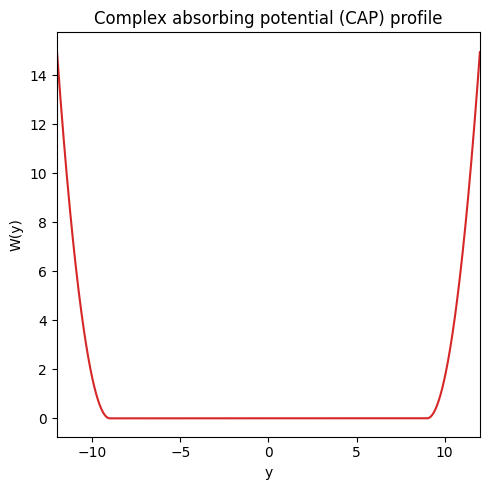

In [5]:
# --- Time grid ---
dt    = 0.005      # time step
T     = 12.00      # total simulation time
tau   = np.arange(0.0, T + dt, dt)   # [0, dt, 2dt, ..., T]

print(f'Time grid: {len(tau)} points, T={tau[-1]:.3f}, dt={dt}')

# --- Complex absorbing potential (remove or comment out if not needed) ---
#   strength : peak absorption rate — increase if you see reflections from walls
#   width    : thickness of each absorbing layer at each wall
cap_obj = ComplexAbsorbingPotential(strength=15.0, width=3.0, y_max=y_max)
cap_arr = cap_obj(grid.y, 0.0)   # pre-evaluate to a static array

# Set cap_arr = None to disable absorbing boundaries
# cap_arr = None

# --- Visualise the CAP profile ---
if cap_arr is not None:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(grid.y, cap_arr, color='tab:red', lw=1.5)
    ax.set_xlabel('y')
    ax.set_ylabel('W(y)')
    ax.set_title('Complex absorbing potential (CAP) profile')
    ax.set_xlim(-y_max, y_max)
    plt.tight_layout()
    plt.show()
else:
    print(f'There is no cap complex absorbing potential for this simulation.')

---
## 6. Run the simulation

We use the **2nd-order Strang split-step solver** (`split_step_propagate`).  
Swap in `yoshida_step_propagate` for 4th-order accuracy at ~3× the cost.

Setting `time_independent=True` (or wrapping V in `CachedPotential`) tells the
solver to pre-compute all phase factors once — a big speed-up for static potentials.

In [6]:
print('Running simulation ...')

psi_t, diag = split_step_propagate(
    psi0,                      # initial state
    V,                         # potential
    tau,
    grid,
    return_all=True,           # store every time step (needed for the movie)
    time_independent=True,     # V is time-independent → pre-compute phases
    cap=None,                  # absorbing boundaries (None to disable)
)

# psi_t has shape (Nt, N)  — the full wavefunction history
# diag is a dict with 'tau' and 'norm' arrays

print(f'Done.  psi_t shape = {psi_t.shape}')
print(f'Final norm = {diag["norm"][-1]:.4f}  '
      f'(1.0 = no absorption, <1.0 = some probability absorbed by CAP)')

Running simulation ...
Done.  psi_t shape = (2401, 4096)
Final norm = 1.0000  (1.0 = no absorption, <1.0 = some probability absorbed by CAP)


---
## 7. Quick diagnostics

Plot the norm $\langle\psi|\psi\rangle$ over time — a handy check that the
simulation is behaving as expected.

- Flat at 1.0 → norm-conserving (no CAP or perfectly reflecting walls)  
- Decreasing → probability absorbed by the CAP as the packet hits the walls  
- Increasing → something is wrong (step too large, grid too coarse)

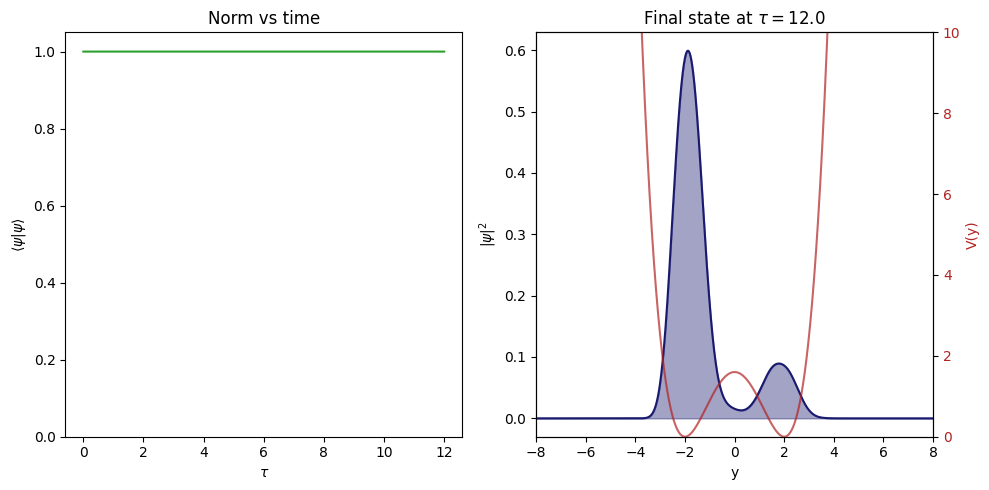

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.0,5.0))

# --- Norm vs time ---
axes[0].plot(diag['tau'], diag['norm'], lw=1.5, color='tab:green')
axes[0].set_xlabel(r'$\tau$')
axes[0].set_ylabel(r'$\langle\psi|\psi\rangle$')
axes[0].set_title('Norm vs time')
axes[0].set_ylim(0.0, 1.05)

# --- Snapshot at final time ---
axes[1].fill_between(grid.y, np.abs(psi_t[-1])**2, alpha=0.4, color='midnightblue')
axes[1].plot(grid.y, np.abs(psi_t[-1])**2, color='midnightblue', lw=1.5,
             label=r'$|\psi(\tau=T)|^2$')

# Overlay the potential on a second y-axis
ax2 = axes[1].twinx()
ax2.plot(grid.y, V(grid.y, diag['tau'][-1]), color='firebrick', lw=1.5, alpha=0.7, label='V(y)')
ax2.set_ylabel('V(y)', color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')
ax2.set_ylim(0.0,10.0)

axes[1].set_xlabel('y')
axes[1].set_ylabel(r'$|\psi|^2$')
axes[1].set_title(f'Final state at $\\tau = {tau[-1]:.1f}$')
axes[1].set_xlim(-8.0,8.0)
#axes[1].set_xlim(-y_max, y_max)

plt.tight_layout()
plt.show()

---
## 8. Make a movie

`make_movie` writes an `.mp4` file and returns the filename.  Key parameters:

| Parameter | Effect |
|-----------|--------|
| `what` | `'abs2'` (probability density), `'abs'`, `'real'`, `'imag'` |
| `stride` | plot every `stride`-th frame — reduce total frames and file size |
| `fps` | frames per second in the output video |
| `potential` | `None`, a static array, or the callable `V` for a time-varying overlay |
| `Vlim` | `(Vmin, Vmax)` for the right-axis potential scale (auto if `None`) |

In [10]:
movie_file = 'playground.mp4'

# stride controls how many frames go into the movie.
# Nt / stride frames total; at fps=30 the movie is (Nt / stride / fps) seconds long.
stride = 5

make_movie(
    psi_t,
    grid,
    diag['tau'],
    outfile=movie_file,
    what='abs2',               # plot |psi|^2
    potential=V,               # draw V(y) on the right axis (callable → time-varying OK)
    stride=stride,
    fps=30,
    dpi=120,
    xlim=(-8.0, 8.0),
    Vlim=(0.00,8.00)
)

print(f'Movie saved to: {movie_file}')

Movie saved to: playground.mp4


## 9. Display the movie

In [12]:
Video(movie_file, embed=True, width=750)

---
## Appendix A — Solver quick-reference

```python
# 2nd-order (Strang) — fast, good for most purposes
psi_t, diag = split_step_propagate(
    psi0, V, tau, grid,
    return_all=True,
    time_independent=True,   # set False if V depends on tau
    cap=cap_arr,             # None to skip absorbing boundaries
)

# 4th-order (Yoshida) — ~3× slower but much more accurate for large dt
psi_t, diag = yoshida_step_propagate(
    psi0, V, tau, grid,
    return_all=True,
    time_independent=True,
    cap=cap_arr,
)
```

Both return:
- `psi_t` — shape `(Nt, N)` complex array (when `return_all=True`)
- `diag`  — dict with `'tau'` and `'norm'` arrays

---
## Appendix B — Potential catalogue

```python
# Harmonic trap (constant frequency)
V = HarmonicPotential(OmegaConstant(omega=1.0))

# Harmonic trap with a slow frequency ramp
V = HarmonicPotential(OmegaRamp(omega_i=1.0, omega_f=2.0, tau0=5.0, delta=1.0))

# Quartic double well  V = lam*(y^2 - a^2)^2
V = QuarticDoubleWell(lam=0.25, a=2.0)

# Gaussian well (attractive) — depth is V0
V = GaussianWell(V0=5.0, sigma=1.0)

# Soft (tanh-smoothed) barrier
V = SoftBarrier(v0=8.0, delta=0.1, w=0.4, x0=0.0)

# Hard square barrier
V = SquareBarrier(v0=8.0, x0=0.0, w=0.5)

# Sum of two potentials
V = Vsum(HarmonicPotential(OmegaConstant(1.0)),
         SoftBarrier(v0=3.0, delta=0.1, w=0.3, x0=0.0))

# Cache a time-independent potential for speed
V = CachedPotential(V_raw)
```

---
## Appendix C — Initial-state catalogue

```python
# Moving Gaussian wavepacket
psi0 = gaussian_wavepacket(grid.y, y0=-7.0, k0=4.0, sigma=0.8)

# Harmonic-oscillator eigenstate (ground state n=0, first excited n=1, ...)
psi0 = ho_eigenstate(grid.y, n=0, Omega=1.0)

# Displaced ground state (coherent state: oscillates classically without spreading)
psi0 = ho_eigenstate(grid.y - 2.0, n=0, Omega=1.0)

# Equal superposition of two eigenstates (beats at Delta E)
psi0 = (ho_eigenstate(grid.y, n=0, Omega=1.0)
       + ho_eigenstate(grid.y, n=1, Omega=1.0)) / np.sqrt(2)
```